In [2]:
#Importing my libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('Mall.csv')

In [4]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
df.drop(columns=['CustomerID', 'Genre'], inplace=True)

In [6]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col]).astype('str')

In [8]:
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

<Axes: >

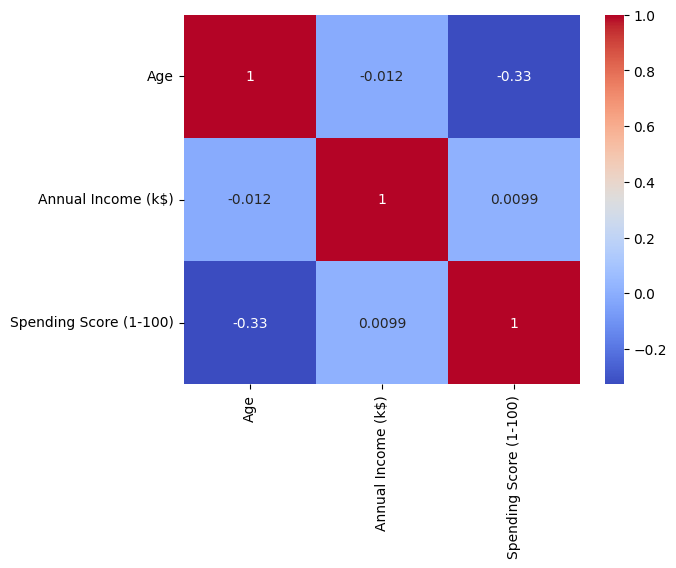

In [9]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [10]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df.values)
print('df shape:', df.shape)
print('df.cols:', df.columns.tolist())

df shape: (200, 3)
df.cols: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [11]:
#testing different k values for k-means, and storing the inertia values for each k
k_range = range(2, 11)
inertias = []

In [12]:
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(x_scaled)
    inertias.append(km.inertia_)
    print(f'k={k:2d}, inertia: {km.inertia_:.2f}')

k= 2, inertia: 389.39
k= 3, inertia: 295.21
k= 4, inertia: 205.23
k= 5, inertia: 168.25
k= 6, inertia: 133.87
k= 7, inertia: 117.01
k= 8, inertia: 103.87
k= 9, inertia: 93.09
k=10, inertia: 82.39


In [13]:
best_k = list(k_range)[inertias.index(min(inertias))]
print(f'Best K based on inertia: {best_k}')

Best K based on inertia: 10


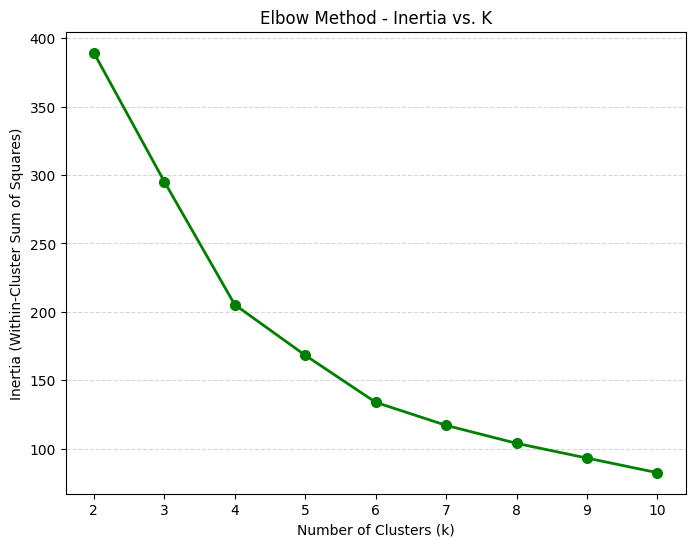

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, marker='o', color='green', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method - Inertia vs. K')
plt.xticks(k_range)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('K-means_Elbow.png', dpi=150)
plt.show()

In [15]:
k_range = range(2, 11)
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k:2d}, silhouette score: {score:.4f}')

k= 2, silhouette score: 0.3355
k= 3, silhouette score: 0.3578
k= 4, silhouette score: 0.4040
k= 5, silhouette score: 0.4166
k= 6, silhouette score: 0.4284
k= 7, silhouette score: 0.4172
k= 8, silhouette score: 0.4082
k= 9, silhouette score: 0.4177
k=10, silhouette score: 0.4066


In [16]:
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f'Best K based on silhouette score: {best_k}')

Best K based on silhouette score: 6


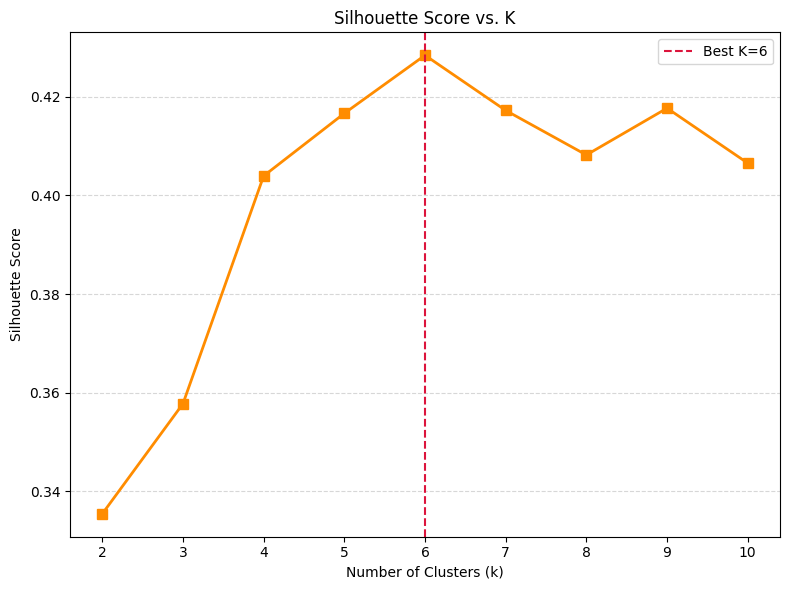

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=7)
plt.axvline(best_k, color='crimson', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score') 
plt.title('Silhouette Score vs. K')
plt.xticks(k_range)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('K-means_Silhouette.png', dpi=150)
plt.show()

In [18]:
# Set best_k from Step 1 (elbow) confirmed by Step 2 (silhouette)
best_k = 3                   # <-- update to your chosen K

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, max_iter=300, tol=1e-4, random_state=42)
km_final.fit(x_scaled)
# Assign cluster labels back to original dataframe
df['Cluster'] = km_final.labels_
print(f'Final K: {best_k}')
print(f'Final Inertia: {km_final.inertia_:.4f}')
print(f'Iteration taken: {km_final.n_iter_}')
print(f'\nCluster Counts:')
print(df['Cluster'].value_counts().sort_index())

Final K: 3
Final Inertia: 295.2122
Iteration taken: 7

Cluster Counts:
Cluster
0    68
1    41
2    91
Name: count, dtype: int64


In [19]:
# 4a. Mean of every feature per cluster
cluster_means = df.groupby('Cluster').mean().round()
print(f'\n--- Cluster Means (Original Scale) ---')
print(cluster_means.to_string())



--- Cluster Means (Original Scale) ---
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        26.0                43.0                    54.0
1        33.0                87.0                    80.0
2        51.0                62.0                    34.0


In [20]:
print(f'\n--- Cluster Descriptive Statistics ---')
for c in sorted(df['Cluster'].unique()):
    print(f'\n Cluster {c} (n = {(df['Cluster']==c).sum()})')
    print(df[df['Cluster']==c].describe().round(3).to_string())


--- Cluster Descriptive Statistics ---

 Cluster 0 (n = 68)
          Age  Annual Income (k$)  Spending Score (1-100)  Cluster
count  68.000              68.000                  68.000     68.0
mean   25.838              42.750                  53.647      0.0
std     6.093              19.416                  23.278      0.0
min    18.000              15.000                   5.000      0.0
25%    20.750              24.000                  41.000      0.0
50%    24.000              40.000                  54.000      0.0
75%    31.000              60.000                  73.000      0.0
max    40.000              81.000                  99.000      0.0

 Cluster 1 (n = 41)
          Age  Annual Income (k$)  Spending Score (1-100)  Cluster
count  41.000              41.000                  41.000     41.0
mean   32.854              87.341                  79.976      1.0
std     3.812              17.986                  13.997      0.0
min    27.000              69.000              

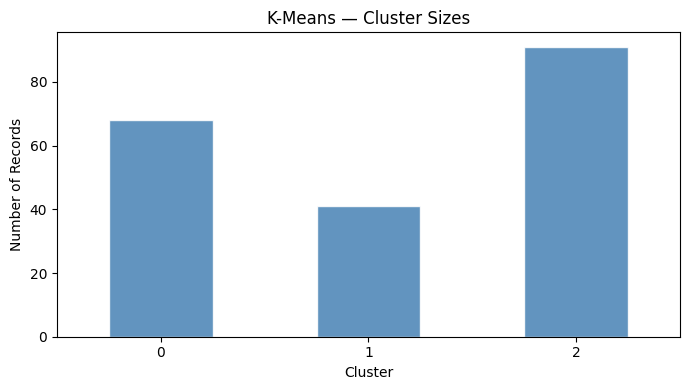

In [21]:
plt.figure(figsize=(7, 4))
df['Cluster'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', alpha=0.85, edgecolor='white')
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.title("K-Means — Cluster Sizes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("kmeans_cluster_sizes.png", dpi=150)
plt.show()


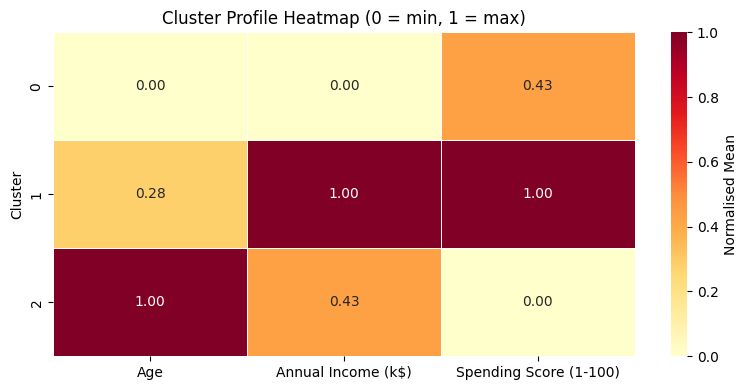

In [22]:
norm_means = (cluster_means - cluster_means.min()) / (
              cluster_means.max() - cluster_means.min())
plt.figure(figsize=(max(8, len(df.columns)*0.8), 4))
sns.heatmap(norm_means, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={'label': 'Normalised Mean'})
plt.title("Cluster Profile Heatmap (0 = min, 1 = max)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("kmeans_cluster_heatmap.png", dpi=150)
plt.show()


In [ ]:
feature_cols = [c for c in df.columns if c != 'Cluster']
n_feat = len(feature_cols)
ncols  = 3
nrows  = (n_feat + ncols - 1) // ncols
 
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n_feat > 1 else [axes]
 
for i, col in enumerate(feature_cols):
    df.boxplot(column=col, by='Cluster', ax=axes[i])
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel('Cluster')
 
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Feature Distributions by Cluster", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_boxplots_by_cluster.png", dpi=150)
plt.show()
 


In [ ]:
pca2 = PCA(n_components=2, random_state=42)
x_2d = pca2.fit_transform(x_scaled)


C:\Users\USER\AppData\Local\Temp\ipykernel_27936\1962082386.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('Set2', best_k)


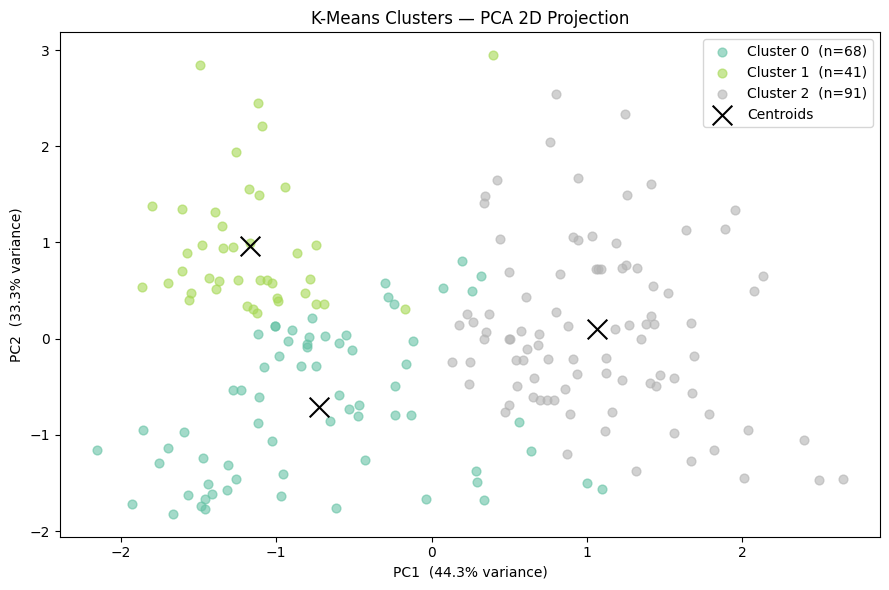

In [ ]:
pca2 = PCA(n_components=2, random_state=42)
x_2d = pca2.fit_transform(x_scaled)
 
# Centroids in PCA space
centroids_2d = pca2.transform(km_final.cluster_centers_)
 
plt.figure(figsize=(9, 6))
palette = plt.cm.get_cmap('Set2', best_k)
for c in range(best_k):
    mask = df['Cluster'] == c
    plt.scatter(x_2d[mask, 0], x_2d[mask, 1],
                color=palette(c), alpha=0.6, s=40,
                label=f'Cluster {c}  (n={mask.sum()})')
 
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            marker='x', s=200, c='black',
            zorder=5, label='Centroids')
plt.xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title("K-Means Clusters — PCA 2D Projection")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_pca2d.png", dpi=150)
plt.show()



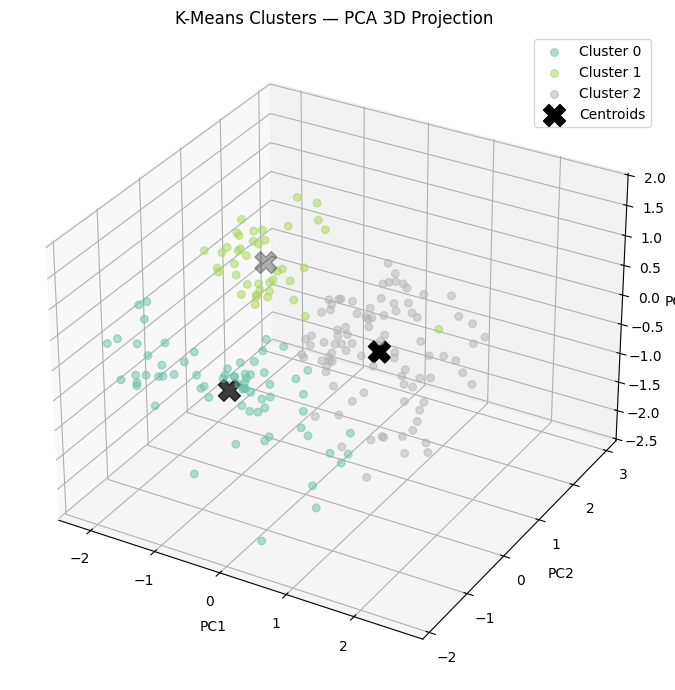

Total variance explained by 3 PCs: 100.0%


In [ ]:
pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(x_scaled)
centroids_3d = pca3.transform(km_final.cluster_centers_)
 
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
 
for c in range(best_k):
    mask = df['Cluster'] == c
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               color=palette(c), alpha=0.5, s=30,
               label=f'Cluster {c}')
 
ax.scatter(centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
           marker='X', s=250, c='black', zorder=5, label='Centroids')
 
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("K-Means Clusters — PCA 3D Projection")
ax.legend()
plt.tight_layout()
plt.savefig("kmeans_pca3d.png", dpi=150)
plt.show()
 
total_var = pca3.explained_variance_ratio_.sum() * 100
print(f"Total variance explained by 3 PCs: {total_var:.1f}%")


In [ ]:
df.to_csv('kmeans_clustered_data.csv', index=False)
print("Saved: kmeans_clustered_data.csv")


Saved: kmeans_clustered_data.csv


In [ ]:
summary = df.groupby('Cluster').agg(['mean','std','min','max']).round(3)
summary.to_csv('kmeans_cluster_summary.csv')
print("Saved: kmeans_cluster_summary.csv")


Saved: kmeans_cluster_summary.csv


In [ ]:
new_point = [[5.1, 3.5, 1.4]]          # Replace with real values
new_scaled = scaler.transform(new_point)
predicted_cluster = km_final.predict(new_scaled)
print(f"\nNew point predicted cluster: {predicted_cluster[0]}")



New point predicted cluster: 0
